# Prove

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_x = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/X_train.csv")
train_y = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/y_train.csv")

train_df = pd.merge(train_x, train_y, on='id')
test_x = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/valid_test_x.csv")
test_y = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/valid_test_y.csv")
test_df = pd.concat([test_x, test_y], axis=1)

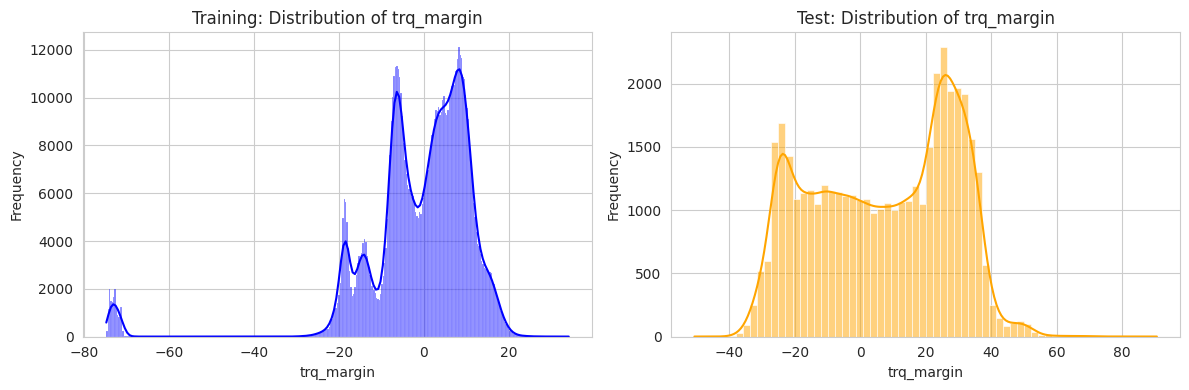

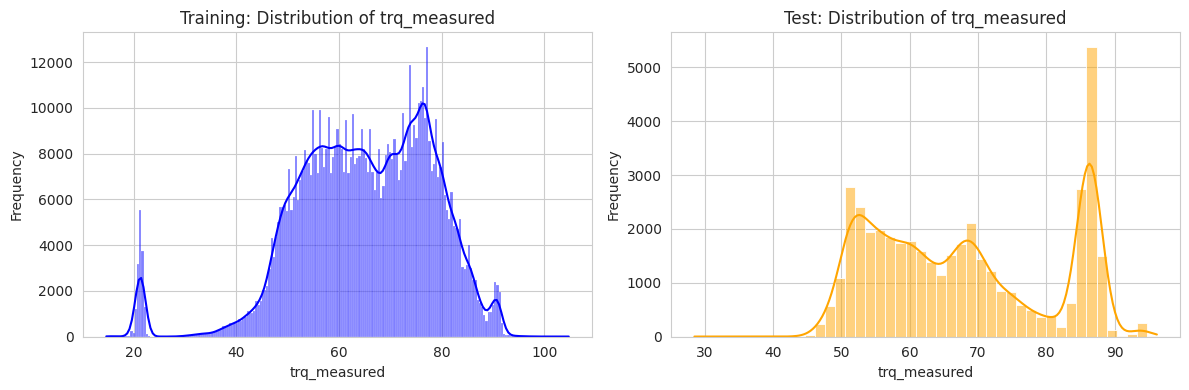

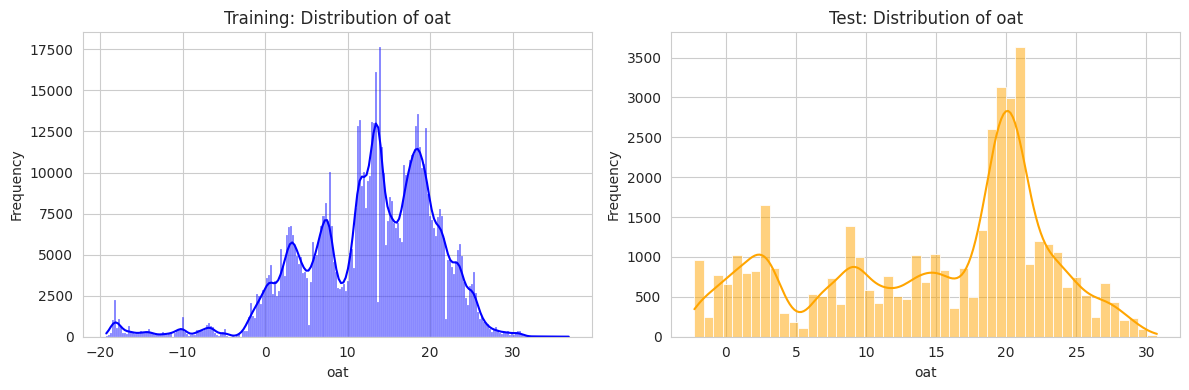

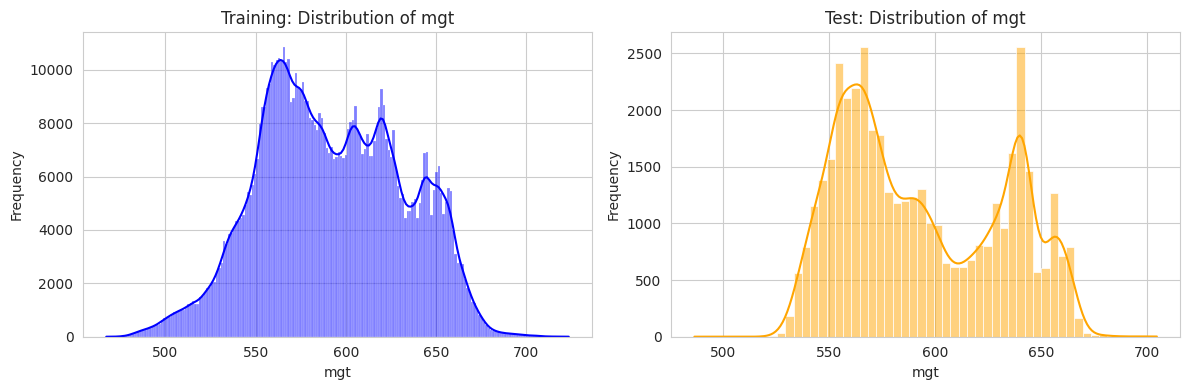

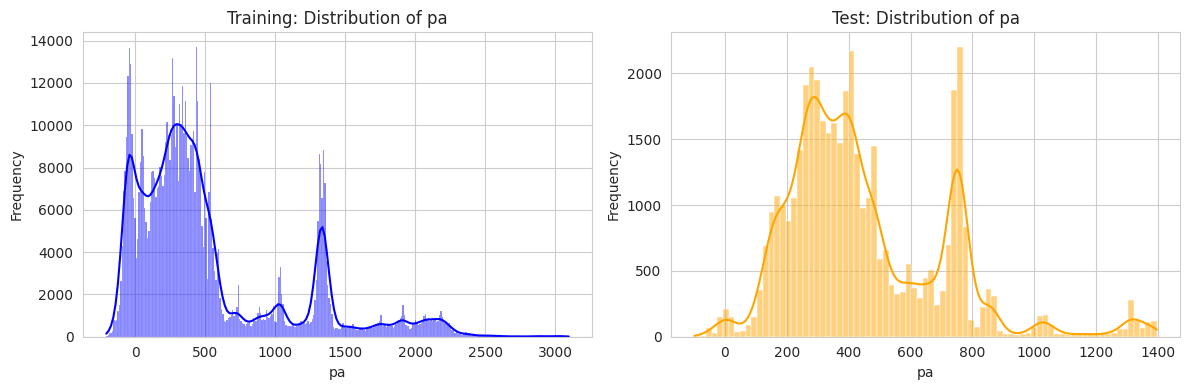

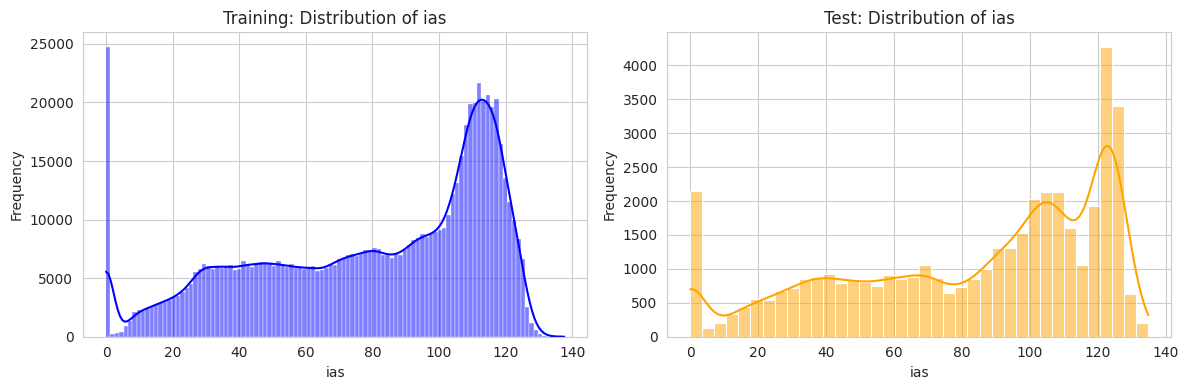

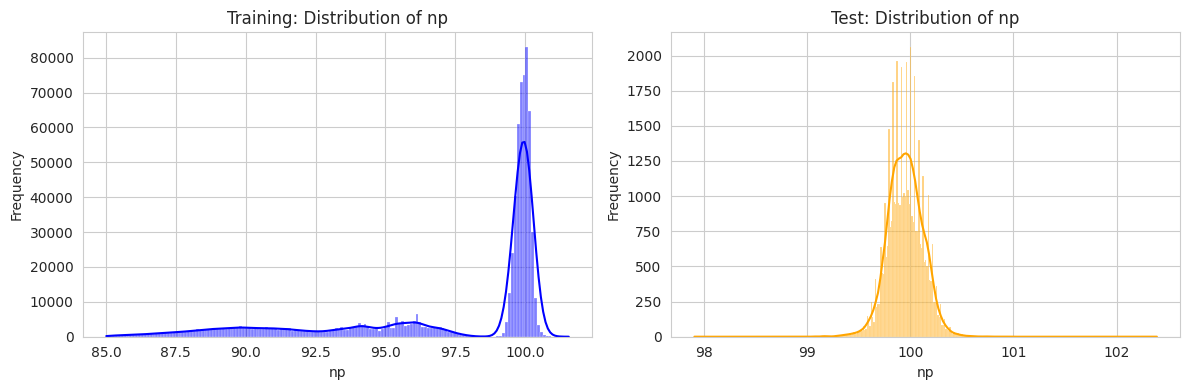

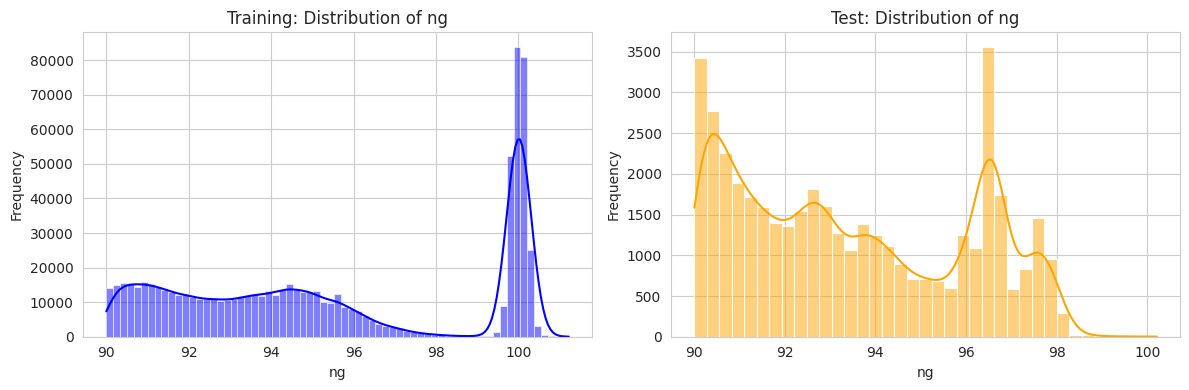

In [39]:
# Distribution difference (traning vs test) -> data drif
features = ['trq_margin', 'trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng']
num_features = len(features)

for feature in features:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(train_df[feature], kde=True, color='blue')
    plt.title(f"Training: Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")


    plt.subplot(1,2,2)
    sns.histplot(test_df[feature], kde=True, color='orange')
    plt.title(f"Test: Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

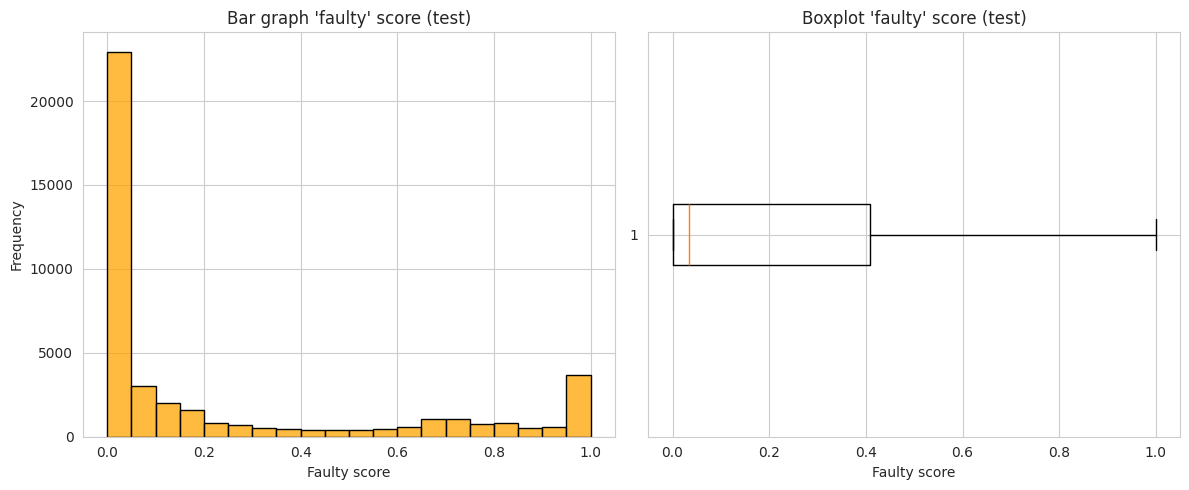

In [38]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(test_df['faulty'], bins=20, color='orange', edgecolor='black')
plt.title("Bar graph 'faulty' score (test)")
plt.xlabel("Faulty score")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.boxplot(test_df['faulty'], vert=False)
plt.title("Boxplot 'faulty' score (test)")
plt.xlabel("Faulty score")
plt.tight_layout()
plt.show()

In [ ]:
#Correlation
corr_train = train_df[features + ['faulty']].corr()
print("Corr. (training) between features and 'faulty':")
print(corr_train['faulty'])


corr_test = test_df[features + ['faulty']].corr()
print("\nCorr. (test) tra le feature e 'faulty confidence':")
print(corr_test['faulty'])


Corr. (training) between features and 'faulty':
trq_margin     -0.605112
trq_measured   -0.132677
oat            -0.338451
mgt             0.184274
pa              0.342304
ias            -0.108341
np              0.134411
ng             -0.090337
faulty          1.000000
Name: faulty, dtype: float64

Corr. (test) tra le feature e 'faulty':
trq_margin     -0.586426
trq_measured   -0.548833
oat             0.275325
mgt            -0.498513
pa              0.204542
ias            -0.287436
np             -0.069957
ng             -0.535221
faulty          1.000000
Name: faulty, dtype: float64


In [36]:
threshold = 0.5
test_df['faulty_bin'] = (test_df['faulty'] >= threshold).astype(int)

corr_bin = test_df[['trq_margin', 'trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'faulty_bin']].corr()
print("Corr. (test) cwith faulty_bin:")
print(corr_bin['faulty_bin'])

Correlazioni (Test) con faulty_bin:
trq_margin     -0.495550
trq_measured   -0.455660
oat             0.209731
mgt            -0.414835
pa              0.217671
ias            -0.234513
np             -0.041427
ng             -0.452702
faulty_bin      1.000000
Name: faulty_bin, dtype: float64


Ci sono differenze nelle correlazioni, sembra che alcune feature assumano maggiore importanza nel test rispetto al training.

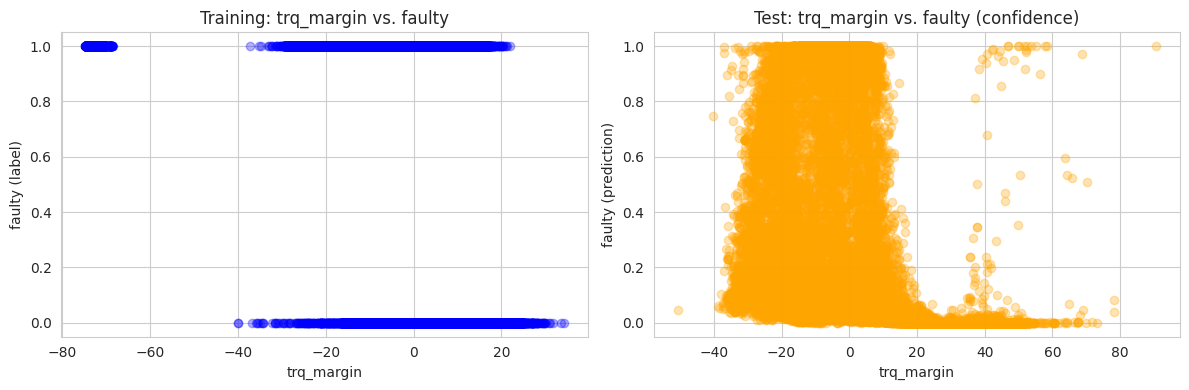

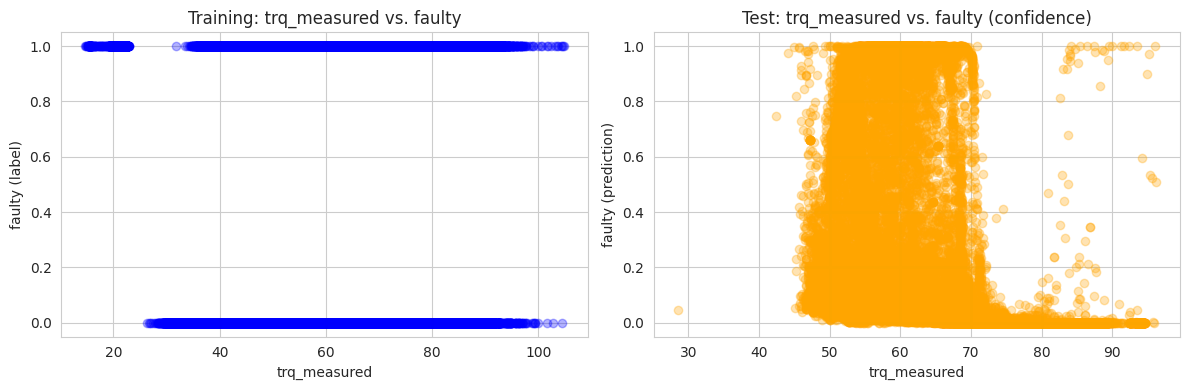

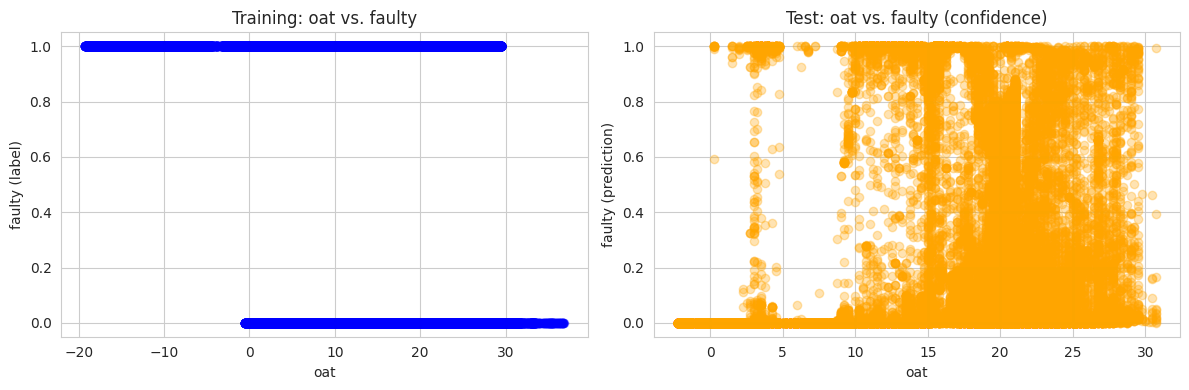

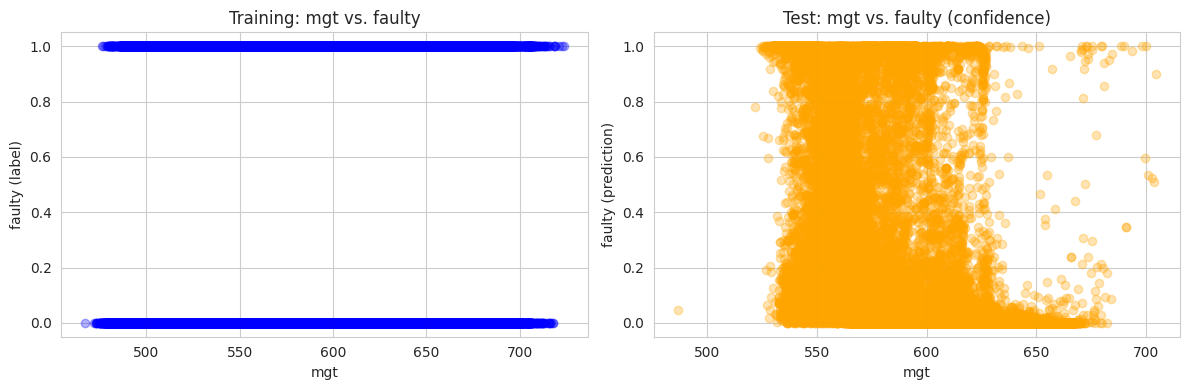

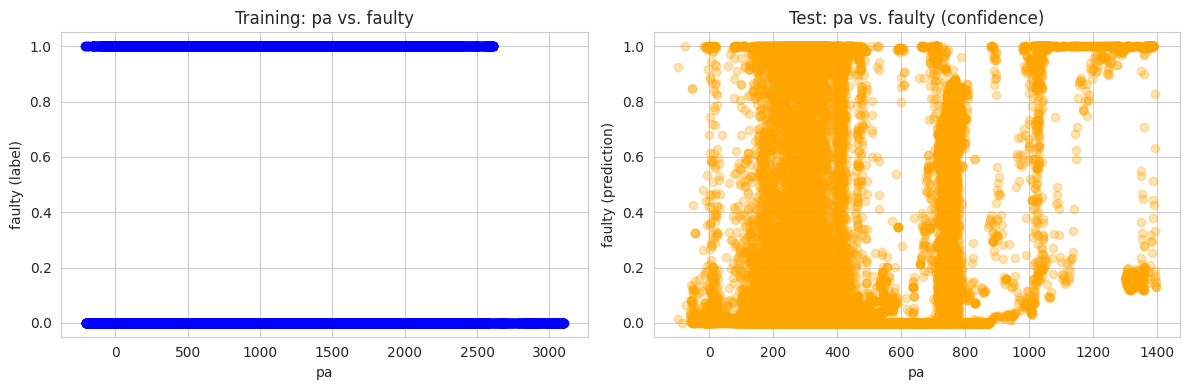

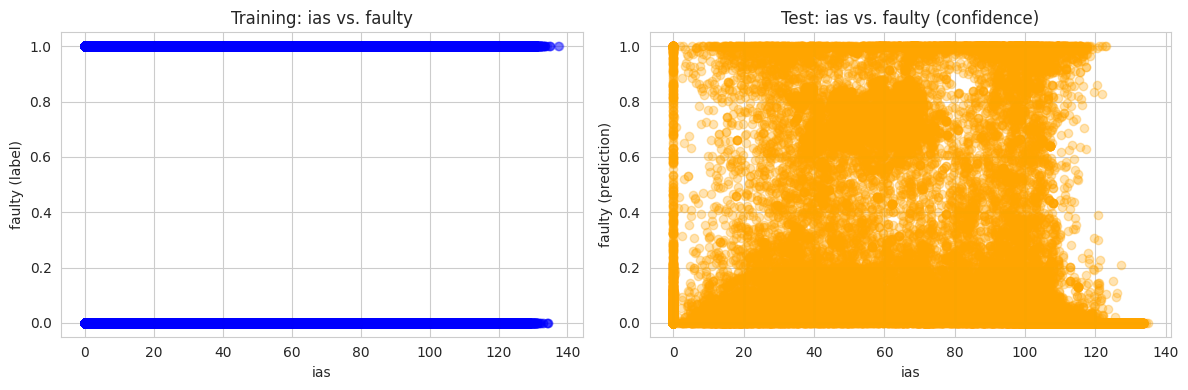

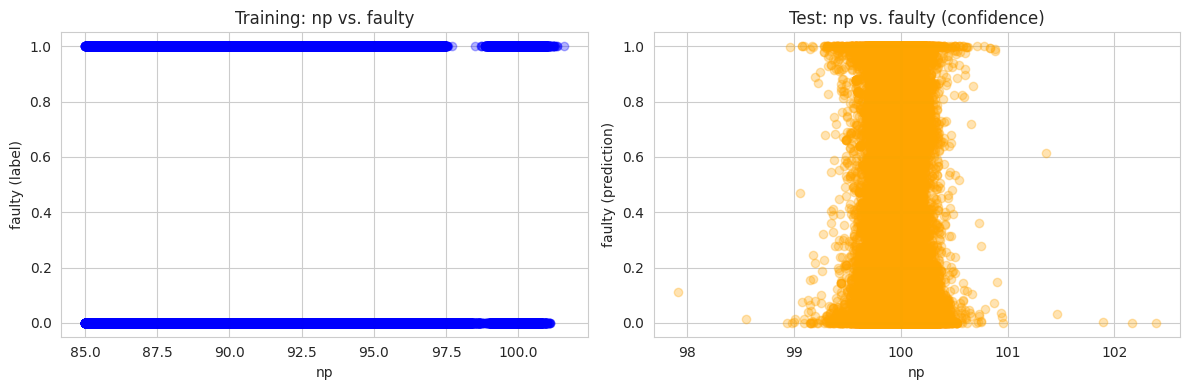

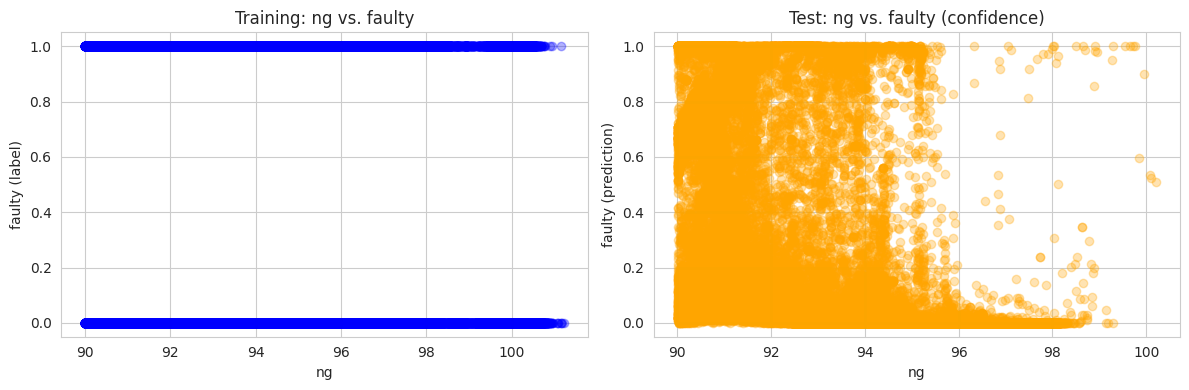

In [40]:
# Features vs Faulty
for feature in features:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.scatter(train_df[feature], train_df['faulty'], alpha=0.3, color='blue')
    plt.title(f"Training: {feature} vs. faulty")
    plt.xlabel(feature)
    plt.ylabel("faulty (label)")

    plt.subplot(1,2,2)
    plt.scatter(test_df[feature], test_df['faulty'], alpha=0.3, color='orange')
    plt.title(f"Test: {feature} vs. faulty (confidence)")
    plt.xlabel(feature)
    plt.ylabel("faulty (prediction)")

    plt.tight_layout()
    plt.show()

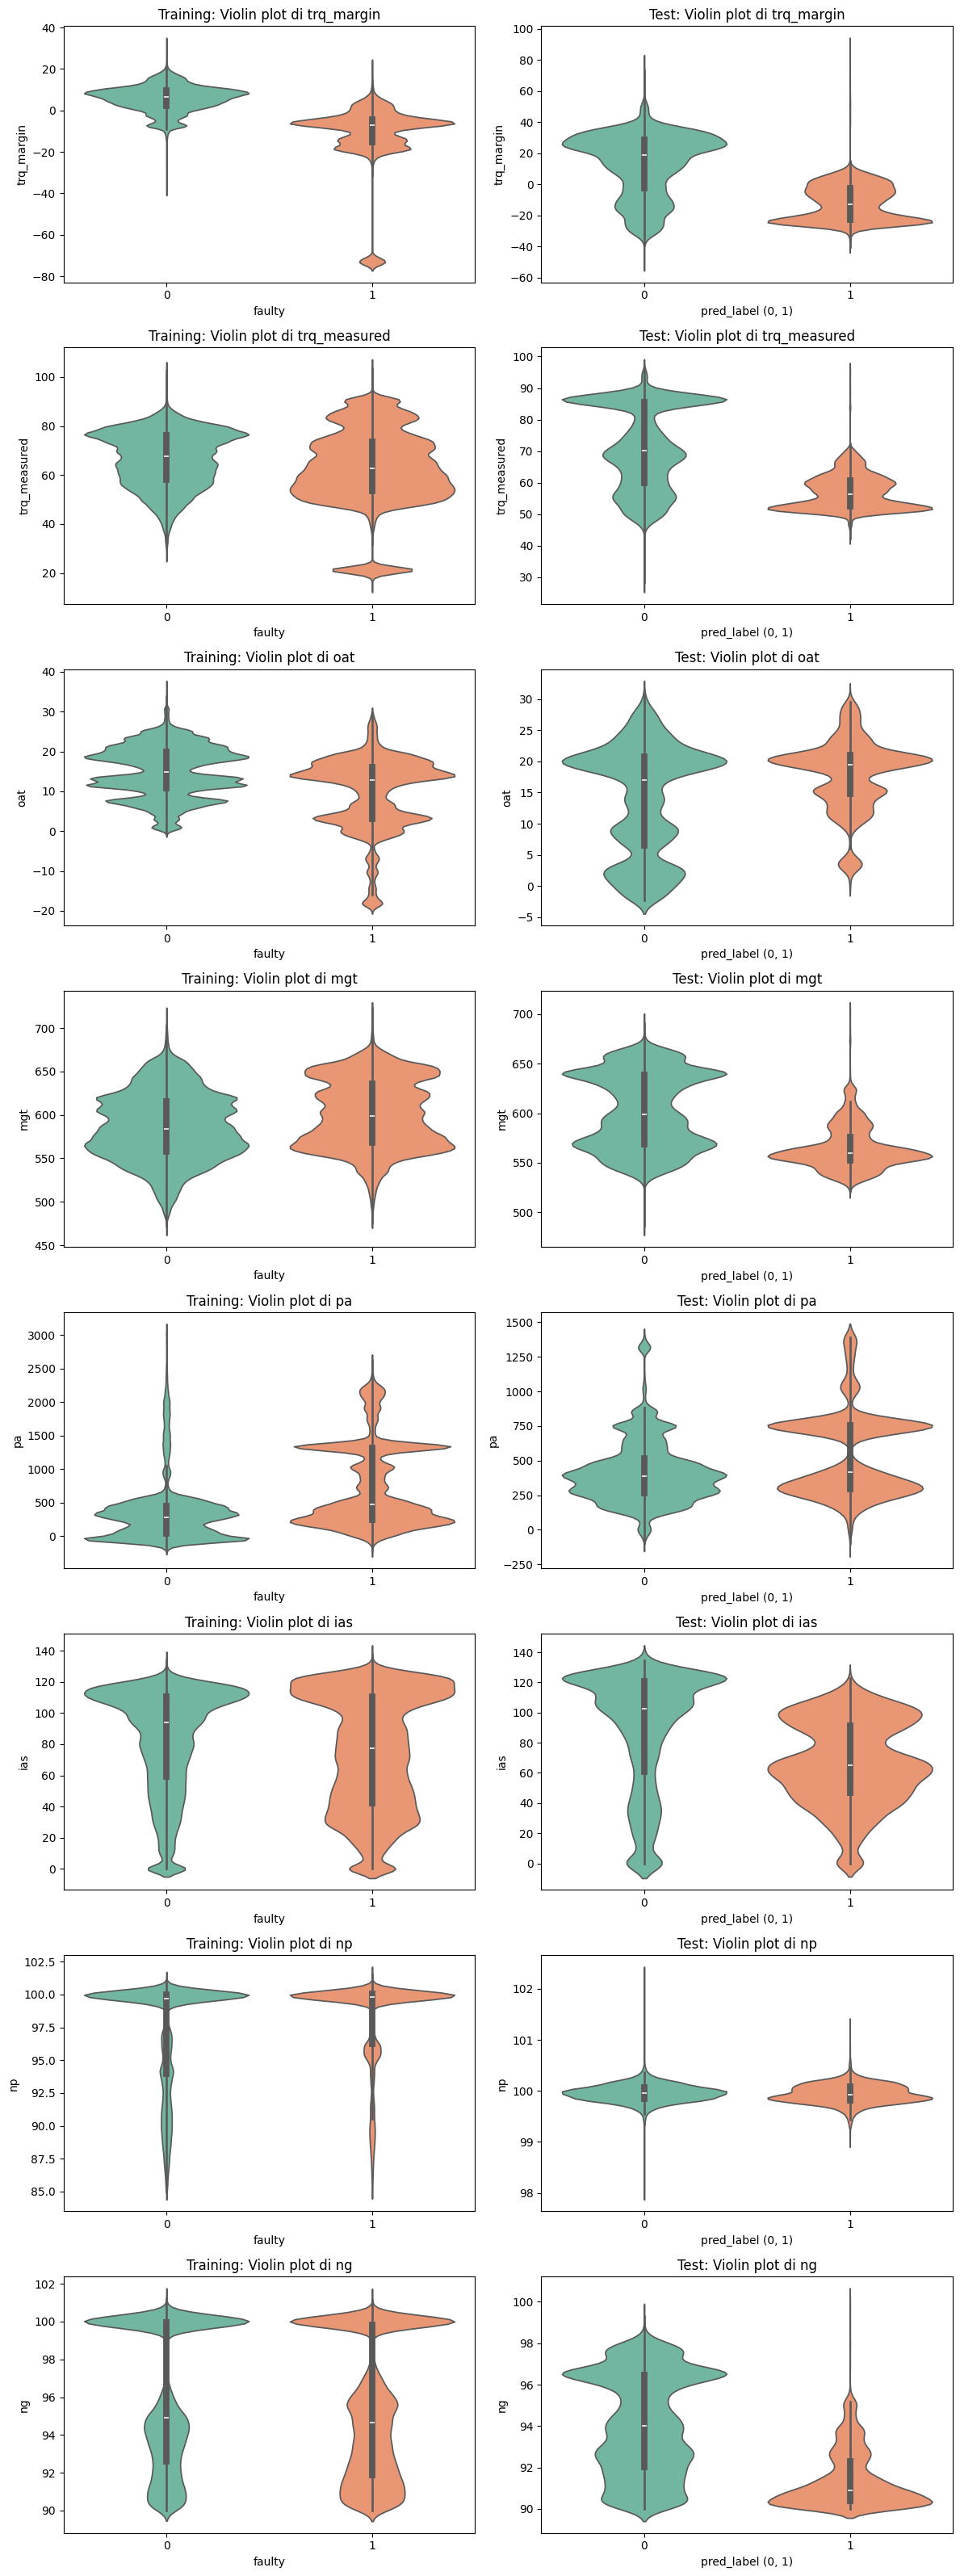

In [ ]:
#Violin plots difference (training vs test)
fig, axes = plt.subplots(nrows=num_features, ncols=2, figsize=(12, 4 * num_features))

for i, feature in enumerate(features):

    sns.violinplot(
        ax=axes[i, 0],
        x='faulty',
        y=feature,
        data=train_df,
        hue='faulty',
        palette='Set2',
        legend=False
    )
    axes[i, 0].set_title(f"Training: Violin plot di {feature}")


    sns.violinplot(
        ax=axes[i, 1],
        x='faulty_bin',
        y=feature,
        data=test_df,
        hue='faulty_bin',
        palette='Set2',
        legend=False
    )
    axes[i, 1].set_title(f"Test: Violin plot di {feature}")
    axes[i, 1].set_xlabel("pred_label (0, 1)")

plt.tight_layout()
plt.show()

Mean score 'faulty' for bin (trq_margin):
trq_margin_bin
<-40          0.395724
-40 to -20    0.488759
-20 to -10    0.423395
-10 to 0      0.512221
0 to 10       0.399114
10 to 20      0.033261
>20           0.002759
Name: faulty, dtype: float64


<ipython-input-42-53d0cccb8967>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_faulty_by_bin = test_df.groupby('trq_margin_bin')['faulty'].mean()


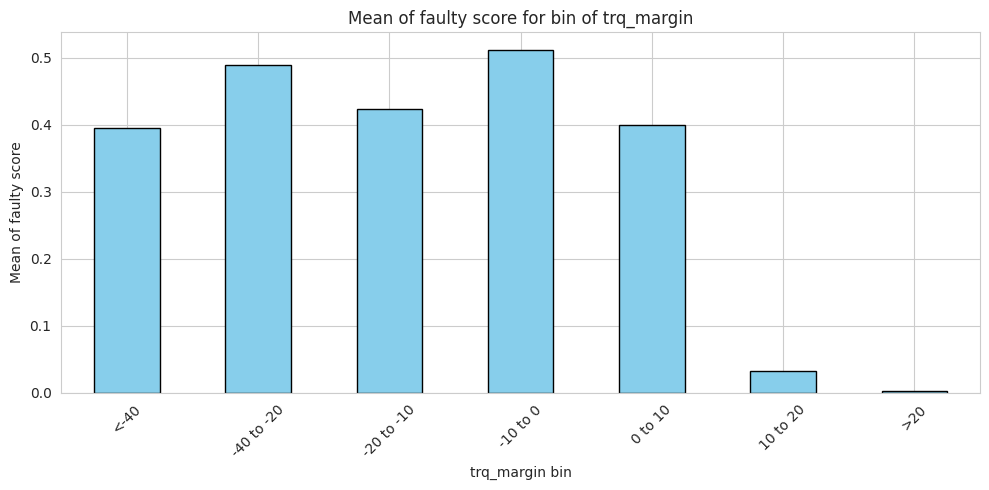

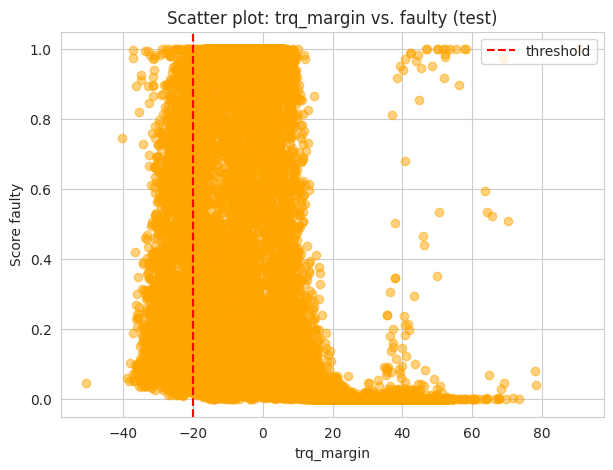

In [42]:
bins = [-float('inf'), -40, -20, -10, 0, 10, 20, float('inf')]
labels = ['<-40', '-40 to -20', '-20 to -10', '-10 to 0', '0 to 10', '10 to 20', '>20']

test_df['trq_margin_bin'] = pd.cut(test_df['trq_margin'], bins=bins, labels=labels)

# Mean faulty (bin)
avg_faulty_by_bin = test_df.groupby('trq_margin_bin')['faulty'].mean()
print("Mean score 'faulty' for bin (trq_margin):")
print(avg_faulty_by_bin)

plt.figure(figsize=(10,5))
avg_faulty_by_bin.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Mean of faulty score for bin of trq_margin")
plt.xlabel("trq_margin bin")
plt.ylabel("Mean of faulty score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
plt.scatter(test_df['trq_margin'], test_df['faulty'], alpha=0.5, color='orange')
plt.title("Scatter plot: trq_margin vs. faulty (test)")
plt.xlabel("trq_margin")
plt.ylabel("Score faulty")
plt.axvline(x=-20, color='red', linestyle='--', label='threshold')
plt.legend()
plt.show()

più il valore di trq_margin è negativo, più è probabile che la confidence faulty sia alto, anche se non è un rapporto perfettamente lineare. Sopra lo 0 maggior parte dei punti ha faulty vicino a 0.

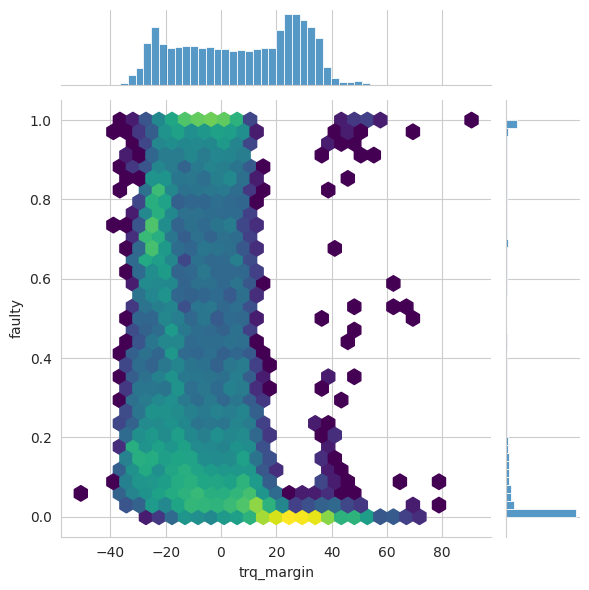

In [ ]:
sns.jointplot(
    data=test_df, x='trq_margin', y='faulty',
    kind='hex', gridsize=30, cmap='viridis',
    marginal_kws=dict(bins=50),
    joint_kws=dict(bins='log')
)

In [ ]:
# Outlier analysis
q1_train = train_df['trq_margin'].quantile(0.25)
q3_train = train_df['trq_margin'].quantile(0.75)
iqr_train = q3_train - q1_train
lower_bound_train = q1_train - 1.5 * iqr_train
upper_bound_train = q3_train + 1.5 * iqr_train
train_outliers = train_df[(train_df['trq_margin'] < lower_bound_train) | (train_df['trq_margin'] > upper_bound_train)]
print("N. of outlier in trq_margin (training):", len(train_outliers))
print(train_outliers[['id', 'trq_margin', 'faulty']].head())


q1_test = test_df['trq_margin'].quantile(0.25)
q3_test = test_df['trq_margin'].quantile(0.75)
iqr_test = q3_test - q1_test
lower_bound_test = q1_test - 1.5 * iqr_test
upper_bound_test = q3_test + 1.5 * iqr_test
test_outliers = test_df[(test_df['trq_margin'] < lower_bound_test) | (test_df['trq_margin'] > upper_bound_test)]
print("N. of outlier in trq_margin (test):", len(test_outliers))
print(test_outliers[['id', 'trq_margin', 'faulty']].head())

N. of outlier in trq_margin (training): 15746
      id  trq_margin  faulty
30    30  -71.712109       1
38    38  -72.819916       1
65    65  -71.476149       1
76    76  -72.336571       1
210  210  -71.728535       1
N. of outlier in trq_margin (test): 1
        id  trq_margin    faulty
22189  753   90.597031  0.999927


In [35]:
outlier_df = test_df[test_df['trq_margin'] > 80]

if not outlier_df.empty:
    for col in ['oat', 'trq_measured', 'mgt', 'pa', 'ias', 'np', 'ng']:
        val = outlier_df[col].values
        print(f"{col} for the outlier: {val}")


        q_low = test_df[col].quantile(0.05)
        q_high = test_df[col].quantile(0.95)
        print(f"Range 5-95% of '{col}' on test set: {q_low} - {q_high}\n")

oat for the outlier: [19.5]
Range 5-95% of 'oat' on test set: 0.0 - 25.75

trq_measured for the outlier: [96.]
Range 5-95% of 'trq_measured' on test set: 50.7 - 87.3

mgt for the outlier: [671.]
Range 5-95% of 'mgt' on test set: 542.955 - 656.9

pa for the outlier: [187.7568]
Range 5-95% of 'pa' on test set: 144.78 - 855.4059599999991

ias for the outlier: [27.25]
Range 5-95% of 'ias' on test set: 3.8468750000000114 - 125.625

np for the outlier: [100.24]
Range 5-95% of 'np' on test set: 99.69 - 100.22

ng for the outlier: [98.65]
Range 5-95% of 'ng' on test set: 90.18 - 97.58



Non è solo trq_margin a essere fuori scala: anche mgt, np e ng risultano superiori ai valori del 95°-> il motore potrebbe trovarsi in operative anomale